In [1]:
!pip install torchdiffeq

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [2]:
import matplotlib.pyplot as plt
import os
import argparse
import time
import numpy as np
import IPython
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torchdiffeq import odeint
from scipy.interpolate import BSpline

In [3]:
import sys
if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py"
    import helper
    helper.install_idaes()
    helper.install_ipopt()
    !pyomo build-extensions

--2024-05-21 23:10:51--  https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7171 (7.0K) [text/plain]
Saving to: ‘helper.py’

helper.py           100%[===================>]   7.00K  --.-KB/s    in 0s      

2024-05-21 23:10:51 (84.2 MB/s) - ‘helper.py’ saved [7171/7171]

Installing idaes via pip...
idaes was successfully installed
Running idaes get-extensions to install Ipopt, k_aug, and more...
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)

[K_AUG] 0.1.0, Part of the IDAES PSE framework
Please visit https://idaes.org/ (x86_64-pc-linux-gnu), ASL(20190605)

Couenne 0.5.8 -- an Open-Source solver for Mixed Integer Nonlinear Optimization
Mailing list: couenne@list.coin-or.org
Instructions

In [4]:
import tensorflow.keras as k
from pyomo.environ import *
from pyomo.dae import *

In [5]:
!pip install git+https://github.com/cog-imperial/OMLT.git

  Cloning https://github.com/cog-imperial/OMLT.git to /tmp/pip-req-build-lqt39nmw
  Running command git clone --filter=blob:none --quiet https://github.com/cog-imperial/OMLT.git /tmp/pip-req-build-lqt39nmw
  Resolved https://github.com/cog-imperial/OMLT.git to commit e60563859a66ac5dd3348bf1763de57eec95171e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 25.1 MB/s eta 0:00:00
  Created wheel for omlt: filename=omlt-1.1.post1.dev121+ge605638-py2.py3-none-any.whl size=54368 sha256=201897d36a397a921caa26d3686750d30fb58f3618979df6e91f0a43828d4b04
  Stored in directory: /tmp/pip-ephem-wheel-cache-25scwgdj/wheels/53/93/d9/b409664fba5342c98ad450fa3d16c577f8a9996068e8c513d0
Successfully built omlt
  Attempting uninstall: pyomo
    Found existing installation: Pyomo 6.7.2
    Uninstalling Pyomo-6.7.2:
      Successfully uninstalled Pyomo-6.7.2
ERROR: 

In [6]:
from omlt import OmltBlock, OffsetScaling
from omlt.neuralnet import FullSpaceNNFormulation, NetworkDefinition,ReluBigMFormulation,ReluComplementarityFormulation,ReducedSpaceNNFormulation
from omlt.io import load_keras_sequential

The class '_BlockData' has been renamed to 'BlockData'.  (deprecated
in 6.7.2)
(called from /usr/local/lib/python3.10/dist-packages/omlt/block.py:33)


In [7]:
m=ConcreteModel()
m.tf=Param(initialize=1)
m.t =ContinuousSet(bounds=(0,m.tf))

m.u=Var(m.t,initialize=0)
m.x1=Var(m.t)
m.x2=Var(m.t)
m.x3=Var(m.t)

m.dx1dt = DerivativeVar(m.x1,wrt=m.t)
m.dx2dt = DerivativeVar(m.x2,wrt=m.t)
m.dx3dt = DerivativeVar(m.x3,wrt=m.t)

m.obj = Objective(expr=m.x3[m.tf])

def _x1dot(m,t):
  return m.dx1dt[t] == m.x2[t]
m.x1dot=Constraint(m.t, rule=_x1dot)
def _x2dot(m,t):
  return m.dx2dt[t] == -m.x2[t] +m.u[t]
m.x2dot=Constraint(m.t, rule=_x2dot)
def _x3dot(m,t):
  return m.dx3dt[t] == m.x1[t]**2 +m.x2[t]**2+0.005*m.u[t]**2
m.x3dot=Constraint(m.t, rule=_x3dot)

def _con(m,t):
  return m.x2[t]-8*(t-0.5)**2+0.5<=0
m.con = Constraint(m.t,rule=_con)

def _init(m):
  yield m.x1[0]==0
  yield m.x2[0]==-1
  yield m.x3[0]==0
m.init_conditions=ConstraintList(rule=_init)

In [8]:
discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=20, ncp=1, scheme='LAGRANGE-RADAU')
#discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.t)

solver = SolverFactory('ipopt')

results = solver.solve(m, tee=True)

x1 = []
x2 = []
x3 = []
u = []
t = []

print(sorted(m.t))

for i in sorted(m.t):
    t.append(i)
    x1.append(value(m.x1[i]))
    x2.append(value(m.x2[i]))
    x3.append(value(m.x3[i]))
    u.append(value(m.u[i]))

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

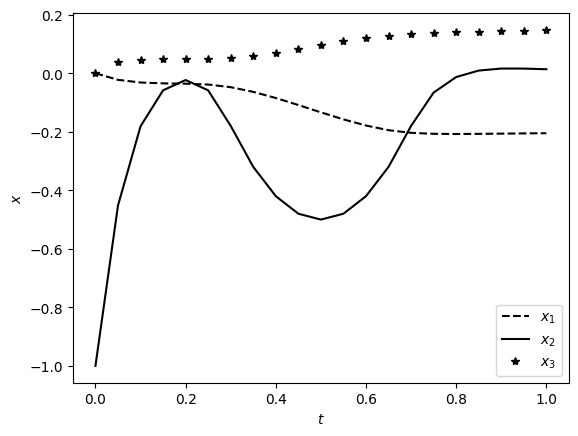

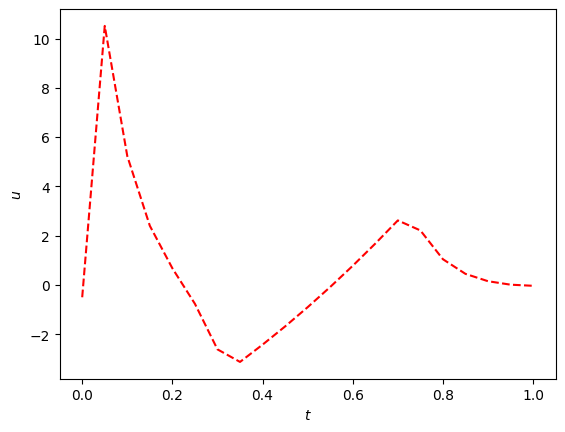

In [9]:
plt.plot(t, x1,'k--')
plt.plot(t, x2,'k-')
plt.plot(t, x3,'k*')
plt.xlabel('$t$')
plt.ylabel('$x$')
plt.legend(['$x_1$','$x_2$','$x_3$'])
plt.show()

plt.plot(t, u,'r--')
plt.xlabel('$t$')
plt.ylabel('$u$')

plt.show()

In [10]:
!pip install pyDOE

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18168 sha256=831b0679180d05d3cab4893d3701c700c5d21f896754da74316e125ddd625e2d
  Stored in directory: /root/.cache/pip/wheels/ce/b6/d7/c6b64746dba6433c593e471e0ac3acf4f36040456d1d160d17
Successfully built pyDOE


In [117]:
from pyDOE import lhs

# Define the number of samples and dimensions
num_samples = 65
num_dimensions = 4
# X V P S U
# Define the upper and lower bounds for each variable
bounds = np.array([[-0.5, 0.5], [-0.5, 0.5], [-1, 0.5], [-10, 20]])

# Generate Latin Hypercube Samples
lhs_samples = lhs(num_dimensions, samples=num_samples, criterion='center')

# Rescale the samples to the specified bounds
scaled_samples = bounds[:, 0] + lhs_samples * (bounds[:, 1] - bounds[:, 0])

In [118]:
def model_sample(y, t):
    X1=y[:,0]
    X2=y[:,1]
    X3=y[:,2]
    U=y[:,3]

    dX1dt = X2
    dX2dt = -X2+U
    dX3dt = X1**2+X2**2+0.005*U**2
    return np.column_stack((dX1dt,dX2dt,dX3dt))

In [119]:
y_samp=model_sample(scaled_samples,1)

In [130]:
from sklearn.model_selection import train_test_split


X_train, X_val, Y_train, Y_val = train_test_split(scaled_samples, y_samp, test_size=0.2, random_state=42)
model_tf=k.Sequential()
model_tf.add(k.layers.Dense(50,activation='tanh', input_shape=(4,)))
#model.add(k.layers.Dense(50,activation='relu'))
model_tf.add(k.layers.Dense(3))

model_tf.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model

# Train the model
history = model_tf.fit(X_train, Y_train, epochs=1000, batch_size=32, validation_data=(X_val, Y_val))

Epoch 1/1000
2/2 [==============================] - 1s 152ms/step - loss: 32.4976 - val_loss: 35.1958
Epoch 2/1000
2/2 [==============================] - 0s 30ms/step - loss: 31.8214 - val_loss: 34.4639
Epoch 3/1000
2/2 [==============================] - 0s 28ms/step - loss: 31.1449 - val_loss: 33.7434
Epoch 4/1000
2/2 [==============================] - 0s 29ms/step - loss: 30.4866 - val_loss: 33.0367
Epoch 5/1000
2/2 [==============================] - 0s 36ms/step - loss: 29.7949 - val_loss: 32.3474
Epoch 6/1000
2/2 [==============================] - 0s 29ms/step - loss: 29.1643 - val_loss: 31.6689
Epoch 7/1000
2/2 [==============================] - 0s 30ms/step - loss: 28.5434 - val_loss: 31.0037
Epoch 8/1000
2/2 [==============================] - 0s 33ms/step - loss: 27.8984 - val_loss: 30.3547
Epoch 9/1000
2/2 [==============================] - 0s 34ms/step - loss: 27.3040 - val_loss: 29.7177
Epoch 10/1000
2/2 [==============================] - 0s 29ms/step - loss: 26.7223 - val_lo

In [137]:
history = model_tf.fit(X_train, Y_train, epochs=1000,  validation_data=(X_val, Y_val))

Epoch 1/1000
2/2 [==============================] - 0s 85ms/step - loss: 0.0017 - val_loss: 0.0064
Epoch 2/1000
2/2 [==============================] - 0s 31ms/step - loss: 0.0017 - val_loss: 0.0066
Epoch 3/1000
2/2 [==============================] - 0s 29ms/step - loss: 0.0016 - val_loss: 0.0066
Epoch 4/1000
2/2 [==============================] - 0s 28ms/step - loss: 0.0017 - val_loss: 0.0064
Epoch 5/1000
2/2 [==============================] - 0s 33ms/step - loss: 0.0016 - val_loss: 0.0065
Epoch 6/1000
2/2 [==============================] - 0s 30ms/step - loss: 0.0016 - val_loss: 0.0065
Epoch 7/1000
2/2 [==============================] - 0s 30ms/step - loss: 0.0016 - val_loss: 0.0067
Epoch 8/1000
2/2 [==============================] - 0s 30ms/step - loss: 0.0016 - val_loss: 0.0066
Epoch 9/1000
2/2 [==============================] - 0s 31ms/step - loss: 0.0017 - val_loss: 0.0065
Epoch 10/1000
2/2 [==============================] - 0s 29ms/step - loss: 0.0016 - val_loss: 0.0063
Epoch 11/

In [145]:
model_tf.save('CS2_tanh_50_LHS.h5')

In [146]:
def _con_out1(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dx1dt[t] == OM.nn[t].m.outputs[0]#dX V P S U


def _con_out2(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dx2dt[t] == OM.nn[t].m.outputs[1]#dx2dt

def _con_out3(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dx3dt[t] == OM.nn[t].m.outputs[2] #dx2dt




def _con_in1(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.x1[t] == OM.nn[t].m.inputs[0] #x1


def _con_in2(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.x2[t] == OM.nn[t].m.inputs[1]  #x2


def _con_in3(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.x3[t] == OM.nn[t].m.inputs[2]  #u

def _con_in4(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.u[t] == OM.nn[t].m.inputs[3] #u

In [147]:
OM=ConcreteModel()
OM.tf=Param(initialize=1)
OM.t =ContinuousSet(bounds=(0,OM.tf))

OM.u=Var(OM.t,initialize=0)
OM.x1=Var(OM.t)
OM.x2=Var(OM.t)
OM.x3=Var(OM.t)

OM.dx1dt = DerivativeVar(OM.x1,wrt=OM.t)
OM.dx2dt = DerivativeVar(OM.x2,wrt=OM.t)
OM.dx3dt = DerivativeVar(OM.x3,wrt=OM.t)

OM.obj = Objective(expr=OM.x3[OM.tf])

def _con(m,t):
  return m.x2[t]-8*(t-0.5)**2+0.5<=0
OM.con = Constraint(OM.t,rule=_con)

discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(OM, nfe=20, ncp=1, scheme='LAGRANGE-RADAU')

net=load_keras_sequential(model_tf)
#formulation = ReluComplementarityFormulation(net)
formulation = ReducedSpaceNNFormulation(net)
OM.nn=Block(OM.t)
for t in OM.t:
  OM.nn[t].m=OmltBlock()
  OM.nn[t].m.build_formulation(formulation)

#OM.nn[t].out1=Constraint(OM.t, rule=_con_out1)
#OM.nn[t].out2=Constraint(OM.t, rule=_con_out2)
#OM.nn[t].out3=Constraint(OM.t, rule=_con_out3)
#OM.nn[t].out4=Constraint(OM.t, rule=_con_out4)
#OM.nn[t].in1=Constraint(OM.t, rule=_con_in1)
#OM.nn[t].in2=Constraint(OM.t, rule=_con_in2)
#OM.nn[t].in3=Constraint(OM.t, rule=_con_in3)
#OM.nn[t].in4=Constraint(OM.t, rule=_con_in4)
#OM.nn[t].in5=Constraint(OM.t, rule=_con_in5)
OM.out1=Constraint(OM.t, rule=_con_out1)
OM.out2=Constraint(OM.t, rule=_con_out2)
OM.out3=Constraint(OM.t, rule=_con_out3)
#OM.out4=Constraint(OM.t, rule=_con_out4)
OM.in1=Constraint(OM.t, rule=_con_in1)
OM.in2=Constraint(OM.t, rule=_con_in2)
OM.in3=Constraint(OM.t, rule=_con_in3)
OM.in4=Constraint(OM.t, rule=_con_in4)
#OM.in5=Constraint(OM.t, rule=_con_in5)

In [148]:
def _init(m):
  yield m.x1[0]==0
  yield m.x2[0]==-1
  yield m.x3[0]==0
OM.init_conditions=ConstraintList(rule=_init)

#OM.U[0].fix(50.0)

In [149]:
solver = SolverFactory('ipopt')

results = solver.solve(OM, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [142]:
x1_N = []
x2_N = []
x3_N = []
u_N = []
t_N = []

print(sorted(OM.t))

for i in sorted(OM.t):
    t_N.append(i)
    x1_N.append(value(OM.x1[i]))
    x2_N.append(value(OM.x2[i]))
    x3_N.append(value(OM.x3[i]))
    u_N.append(value(OM.u[i]))

[0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]


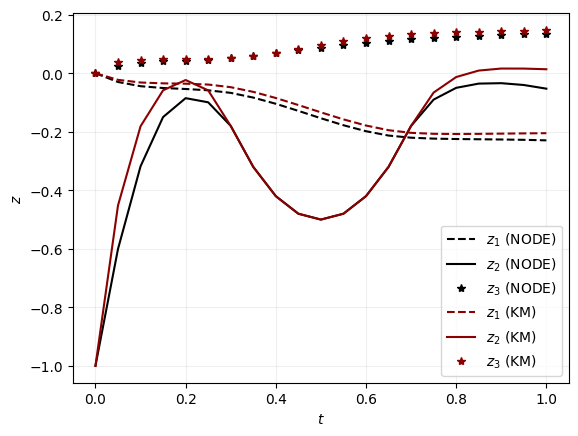

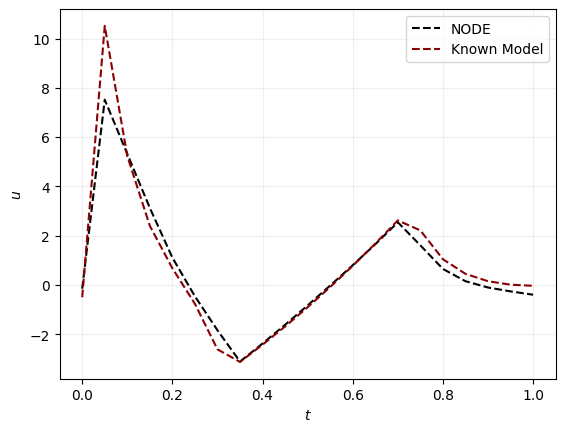

In [144]:
plt.plot(t_N, x1_N,'k--')
plt.plot(t_N, x2_N,'k-')
plt.plot(t_N, x3_N,'k*')
plt.plot(t_N, x1,'--',color='darkred')
plt.plot(t_N, x2,'-',color='darkred')
plt.plot(t_N, x3,'*',color='darkred')
plt.xlabel('$t$')
plt.ylabel('$z$')
plt.legend(['$z_1$ (NODE)','$z_2$ (NODE)','$z_3$ (NODE)','$z_1$ (KM)','$z_2$ (KM)','$z_3$ (KM)'])
plt.grid(True,alpha=0.2)
plt.savefig('CS2_State_tanh_50_LHS.png', dpi=300)
plt.show()

plt.plot(t_N, u_N,'k--')
plt.plot(t_N, u,'--',color='darkred')
plt.xlabel('$t$')
plt.ylabel('$u$')
plt.legend(['NODE','Known Model'])
plt.grid(True,alpha=0.2)
plt.savefig('CS2_Control_tanh_50_LHS.png', dpi=300)
plt.show()